# Tutorial for using the Fitness Landscape Exploration Sandbox

* [Building oracles for landscapes](#section-one)
* [Building a model of the landscape](#section-two)
* [Exploring a landscape with a model](#section-three)
* [Evaluating an exploration algorithm](#section-four)

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import editdistance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pprint
import numpy as np
import json

In [3]:
import flexs
from flexs import baselines
import flexs.utils.sequence_utils as s_utils

2025-01-09 02:10:29.436067: W tensorflow/stream_executor/platform/default/dso_loader.cc:59] Could not load dynamic library 'libcudart.so.10.1'; dlerror: libcudart.so.10.1: cannot open shared object file: No such file or directory
2025-01-09 02:10:29.436111: I tensorflow/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.


## 1. Building oracles for landscapes <a class="anchor" id="section-one"></a>

Most FLEXS landscapes have a problem registry: a dictionary of problems, parameters, and metadata that can be used to quickly generate landscapes and set up interesting benchmarks for models and explorers.

Here we select a landscape that will maximize the negative binding energy of sequences of length 14 against a predefined RNA target.

In [4]:
problem = flexs.landscapes.rna.registry()['L14_RNA1']
pprint.pprint(problem)

{'params': {'seq_length': 14,
            'targets': ['GAACGAGGCACAUUCCGGCUCGCCCGGCCCAUGUGAGCAUGGGCCGGACCCCGUCCGCGCGGGGCCCCCGCGCGGACGGGGGCGAGCCGGAAUGUGCCUC']},
 'starts': ['AUGGGCCGGACCCC',
            'GCCCCGCCGGAAUG',
            'UCUUGGGGACUUUU',
            'GGAUAACAAUUCAU',
            'CCCAUGCGCGAUCA']}


For RNA binding landscapes, the registry contains several starting points of diverse quality and sequence identity on which to evaluate exploration algorithms. We will call our starting point `wt` throughout this tutorial.

In [5]:
starting_sequence = problem['starts'][0]
starting_sequence

'AUGGGCCGGACCCC'

Now we instantiate the landscape and set the sequence alphabet.

In [6]:
landscape = flexs.landscapes.RNABinding(**problem['params'])
alphabet = s_utils.RNAA

In [7]:
alphabet

'UGCA'

You can now query the landscape for ground truth sequence fitnesses

In [8]:
landscape.get_fitness([starting_sequence])

array([0.54374688])

While we show this process on RNA landscapes there are other empirical landscapes that we have similar wrappers around. You can also make your own *custom* landscapes (see examples in `flexs/landscapes`).

Here we demonstrate a rosetta folding landscape, a TF binding landscape, the BERT GFP landscape, and an additive AAV packaging landscape.

In [9]:
rosetta_problem = flexs.landscapes.rosetta.registry()['3mx7']
protein_landscape = flexs.landscapes.RosettaFolding(**rosetta_problem['params'])
protein_wt = protein_landscape.wt_pose.sequence()

print()
pprint.pprint(rosetta_problem)
print(f'\nWT sequence: {protein_wt}, fitness: {protein_landscape.get_fitness([protein_wt])}')

┌──────────────────────────────────────────────────────────────────────────────┐
│                                 PyRosetta-4                                  │
│              Created in JHU by Sergey Lyskov and PyRosetta Team              │
│              (C) Copyright Rosetta Commons Member Institutions               │
│                                                                              │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRE PURCHASE OF A LICENSE │
│         See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└──────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2024 [Rosetta PyRosetta4.Release.python37.ubuntu 2024.42+release.3366cf78a3df04339d1982e94531b77b098ddb99 2024-10-11T08:24:04] retrieved from: http://www.pyrosetta.org

{'params': {'pdb_file': '/home/v-zhaozhiyu/code/FLEXS/src/flexs/flexs/landscapes/data/rosetta/3mx7.pdb',
            'sigmoid_center': -3,
            'sigmoid_norm_value'

In [10]:
tf_binding_problem = flexs.landscapes.tf_binding.registry()['SIX6_REF_R1']
tf_binding_landscape = flexs.landscapes.TFBinding(**tf_binding_problem['params'])
tf_binding_start = tf_binding_problem['starts'][5]

pprint.pprint(tf_binding_problem)
print(f'\nSequence: {tf_binding_start}, fitness: {tf_binding_landscape.get_fitness([tf_binding_start])}')

{'params': {'landscape_file': '/home/v-zhaozhiyu/code/FLEXS/src/flexs/flexs/landscapes/data/tf_binding/SIX6_REF_R1_8mers.txt'},
 'starts': ['GCTCGAGC',
            'GCGCGCGC',
            'TGCGCGCC',
            'ATATAGCC',
            'GTTTGGTA',
            'ATTATGTT',
            'CAGTTTTT',
            'AAAAATTT',
            'AAAAACGC',
            'GTTGTTTT',
            'TGCTTTTT',
            'AAAGATAG',
            'CCTTCTTT',
            'AAAGAGAG']}

Sequence: ATTATGTT, fitness: [0.63142704]


In [11]:
import torch
print(torch.__version__)
print(torch.version.cuda)

1.13.1
None


In [12]:
import os
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'


bert_gfp_landscape = flexs.landscapes.BertGFPBrightness()
bert_gfp_wt = bert_gfp_landscape.gfp_wt_sequence

print(f'WT sequence: {bert_gfp_wt}, fitness: {bert_gfp_landscape.get_fitness([bert_gfp_wt])}')

/home/v-zhaozhiyu/code/FLEXS/src/flexs/flexs/landscapes/bert_gfp.py:78: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /opt/conda/conda-bld/pytorch_1670525496686/work/torch/csrc/utils/tensor_new.cpp:230.)
  [self.tokenizer.encode(seq) for seq in sequences]


WT sequence: MSKGEELFTGVVPILVELDGDVNGHKFSVSGEGEGDATYGKLTLKFICTTGKLPVPWPTLVTTLSYGVQCFSRYPDHMKQHDFFKSAMPEGYVQERTIFFKDDGNYKTRAEVKFEGDTLVNRIELKGIDFKEDGNILGHKLEYNYNSHNVYIMADKQKNGIKVNFKIRHNIEDGSVQLADHYQQNTPIGDGPVLLPDNHYLSTQSALSKDPNEKRDHMVLLEFVTAAGITHGMDELYK, fitness: [3.57232952]


In [14]:
additive_aav_problem = flexs.landscapes.additive_aav_packaging.registry()['liver']
additive_aav_landscape = flexs.landscapes.AdditiveAAVPackaging(**additive_aav_problem['params'])
additive_aav_wt = additive_aav_landscape.wild_type

pprint.pprint(additive_aav_problem)
print(f'WT: {additive_aav_wt}, fitness: {additive_aav_landscape.get_fitness([additive_aav_wt])}')

{'params': {'end': 540, 'phenotype': 'liver', 'start': 450}}
WT: PSGTTTQSRLQFSQAGASDIRDQSRNWLPGPCYRQQRVSKTSADNNNSEYSWTGATKYHLNGRDSLVNPGPAMASHKDDEEKFFPQSGVL, fitness: [0.5]


## 2. Building a model of the landscape <a class="anchor" id="section-two"></a>

In reality, you don't have access to the ground truth landscape oracles except through costly experiments. Instead you can access an approximate version of it either by modeling the landscape through your current observations. In section 2.1 we use what we call a "noisy abstract model" to simulate the situation where you have a model with arbitrary noise. In section 2.2 we show some standard neural nets and use them as models of the landscape. It is easy to implement your own model. All they need to do is to inherit from `flexs.Model` and implement `_fitness_function(sequences)` which gives you the model's estimate of a sequences fitness, and `train(sequences, labels)`.

### 2.1 Abstract model 

This is an abstract model that "emulates" a real model of the landscape. It works by guessing the fitness of a new sequence as a combination of it's real fitness and fitness of the closest known neighbor. 

To build a noisy model, you need to have an oracle, and a `signal_strength` $\alpha \in [0,1]$. This parameter $\alpha$ determines how much your oracle signal is corrupted by noise:

$f_{model}= \alpha^d f_{oracle} + (1-\alpha^d)\epsilon$

here $d$ is the distance to the closest measured neighbor, and $\epsilon$ is a sample from an exponential distribution $\lambda e^{-\lambda x}$, with $\lambda = f_\text{closest_neighbor}$ (for each queried sample, this is sampled once and then fixed for that batch).

In [15]:
noisy_models = [
    baselines.models.NoisyAbstractModel(landscape, signal_strength=ss)
    for ss in [1, 0.9, 0.75, 0]
]

Let's create train and test sets.

In [16]:
train_x = np.array(list(set(s_utils.generate_random_mutant(starting_sequence, 0.2*(i%5), alphabet)
                                 for i in range(0, 10000))))
train_y = landscape.get_fitness(train_x)
print (f'training data consists of {len(train_x)} unique sequences')

test_x = np.array(list(set(s_utils.generate_random_mutant(starting_sequence, 0.2*(i%5), alphabet=alphabet)
                  for i in range(2000))))
test_y = landscape.get_fitness(test_x)

training data consists of 6899 unique sequences


And train the noisy abstract models, each of which have a different signal strength.

In [17]:
for model in noisy_models:
    model.train(train_x, train_y)

Examine the fitness distribution and edit distance distribution of the test set.

We see that the vast majority of sequences have fitness between 0.2 and 0.7. It is challenging to find sequences with fitness above 0.8.

/home/v-zhaozhiyu/miniconda3/envs/FLEXS/lib/python3.7/site-packages/ipykernel_launcher.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  """
/home/v-zhaozhiyu/miniconda3/envs/FLEXS/lib/python3.7/site-packages/ipykernel_launcher.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  import sys


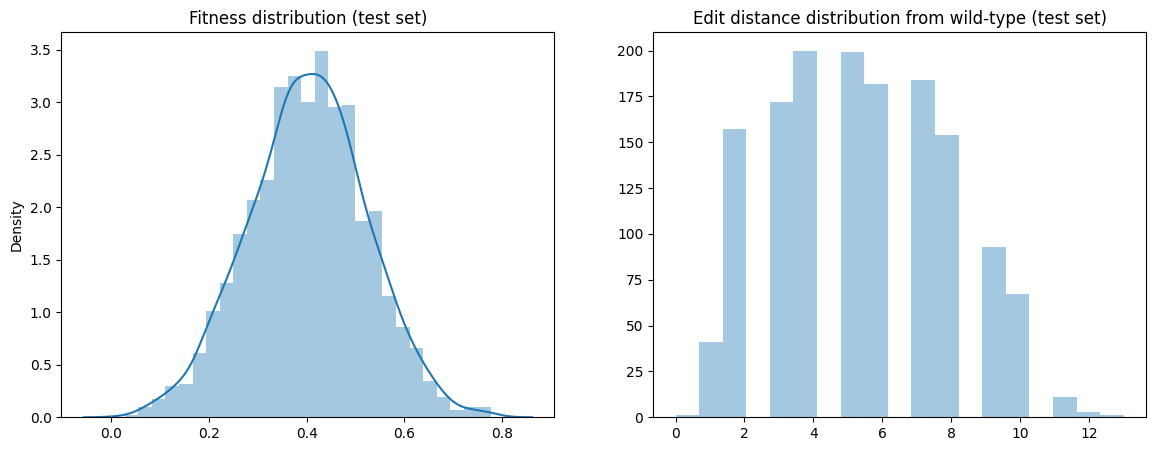

In [18]:
distances = [editdistance.eval(seq, starting_sequence) for seq in test_x]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].set_title('Fitness distribution (test set)')
sns.distplot(test_y, kde=True, ax=ax[0])
ax[1].set_title('Edit distance distribution from wild-type (test set)')
sns.distplot(distances, kde=False, ax=ax[1])
plt.show()

Now we will examine the extrapolation ability (accuracy with respect to edit distance) of noisy abstract models at different signals strengths.

In [19]:
import scipy.stats

def get_corr_per_distance(seqs, labels, preds):    
    corrs = []
    edit_distances = np.array([editdistance.eval(seq, starting_sequence) for seq in seqs])
    
    for dist in range(1, 11):
        seqs_at_dist = edit_distances == dist
        
        if seqs_at_dist.sum() > 50:
            corrs.append(
                scipy.stats.pearsonr(labels[seqs_at_dist], preds[seqs_at_dist])[0]**2
            )
        else:
            corrs.append(np.nan)
            
    return corrs

In [20]:
corrs_noisy_neighbors = [get_corr_per_distance(test_x, test_y, noisy_model.get_fitness(test_x))
                         for noisy_model in noisy_models]

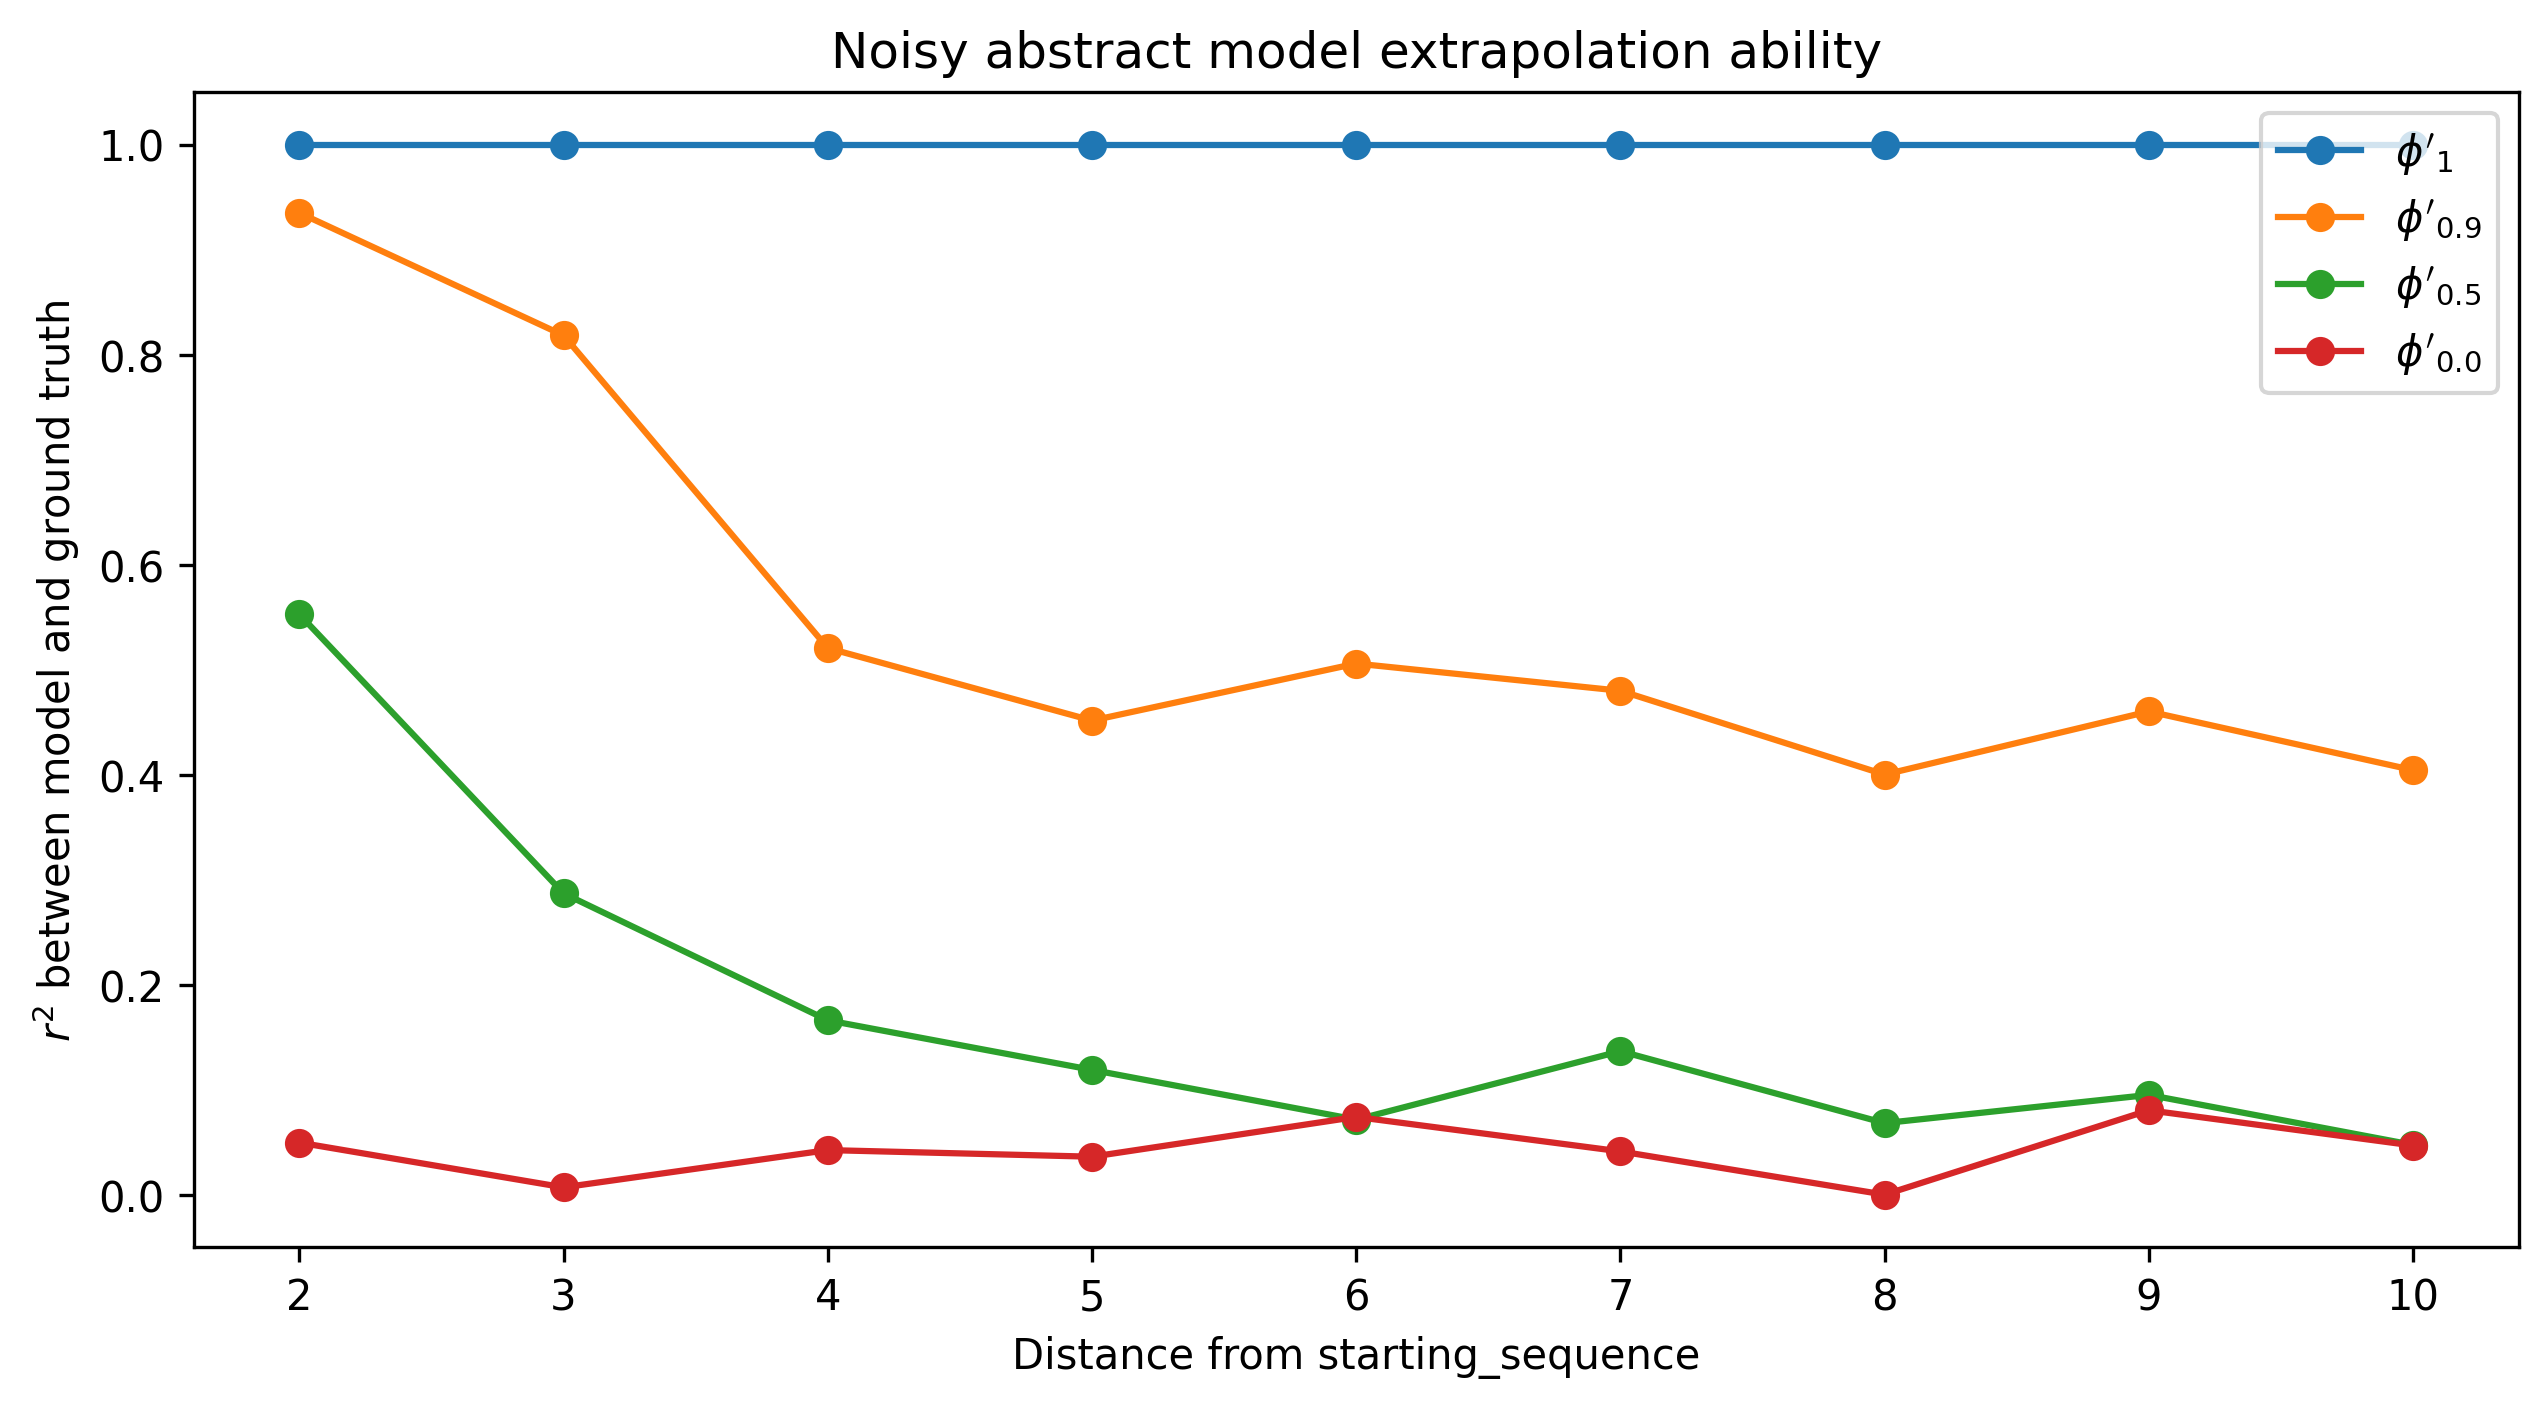

In [21]:
plt.figure(figsize=(10,5), dpi=300)
plt.title('Noisy abstract model extrapolation ability')
plt.plot(range(1,11), corrs_noisy_neighbors[0], 'o-', label="$\phi'_{1}$")
plt.plot(range(1,11), corrs_noisy_neighbors[1], 'o-', label="$\phi'_{0.9}$")
plt.plot(range(1,11), corrs_noisy_neighbors[2], 'o-', label="$\phi'_{0.5}$")
plt.plot(range(1,11), corrs_noisy_neighbors[3], 'o-', label="$\phi'_{0.0}$")
plt.ylabel("$r^2$ between model and ground truth")
plt.xlabel("Distance from starting_sequence")
plt.legend()
plt.show()

### 2.2 Models of landscapes built from data

So far, we have looked at noisy abstract models, are basically corrupted versions of the ground truth landscape. In reality, we don't have immediate access to the ground truth, so we approximate the landscape by training a traditional machine learning model on it. Some basic architectures are provided for convenience.

In [22]:
linear_regression = baselines.models.LinearRegression(alphabet=alphabet)
linear_regression.train(train_x, train_y)

linear_regression_preds = linear_regression.get_fitness(test_x)
corrs_linear = get_corr_per_distance(test_x, test_y, linear_regression_preds)

print(f"Overall correlation: {scipy.stats.pearsonr(linear_regression_preds, test_y)[0]**2}")

Overall correlation: 0.8003759673703881


In [23]:
random_forest = baselines.models.RandomForest(alphabet=alphabet)
random_forest.train(train_x, train_y)

random_forest_preds = random_forest.get_fitness(test_x)
corrs_rf = get_corr_per_distance(test_x, test_y, random_forest_preds)

print(f"Overall correlation: {scipy.stats.pearsonr(random_forest_preds, test_y)[0]**2}")

Overall correlation: 0.7969548523790011


In [24]:
mlp = baselines.models.MLP(len(starting_sequence), hidden_size=100, alphabet=alphabet, loss='MSE')
mlp.train(train_x, train_y)

mlp_preds = mlp.get_fitness(test_x)
corrs_mlp = get_corr_per_distance(test_x, test_y, mlp_preds)

print(f"Overall correlation: {scipy.stats.pearsonr(mlp_preds, test_y)[0]**2}")

2025-01-08 17:12:15.164456: I tensorflow/stream_executor/platform/default/dso_loader.cc:48] Successfully opened dynamic library libcuda.so.1
2025-01-08 17:12:42.690788: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 0 with properties: 
pciBusID: 0001:00:00.0 name: NVIDIA A100 80GB PCIe computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 79.14GiB deviceMemoryBandwidth: 1.76TiB/s
2025-01-08 17:12:42.692712: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 1 with properties: 
pciBusID: 0002:00:00.0 name: NVIDIA A100 80GB PCIe computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 79.14GiB deviceMemoryBandwidth: 1.76TiB/s
2025-01-08 17:12:42.694625: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1716] Found device 2 with properties: 
pciBusID: 0003:00:00.0 name: NVIDIA A100 80GB PCIe computeCapability: 8.0
coreClock: 1.41GHz coreCount: 108 deviceMemorySize: 79.14GiB deviceMemoryBandwidth: 1.76TiB/s
2

Overall correlation: 0.7961901681867488


In [25]:
cnn = baselines.models.CNN(len(starting_sequence), num_filters=32, hidden_size=100, alphabet=alphabet, loss='MSE')
cnn.train(train_x, train_y)

cnn_preds = cnn.get_fitness(test_x)
corrs_cnn = get_corr_per_distance(test_x, test_y, cnn_preds)

print(f"Overall correlation: {scipy.stats.pearsonr(cnn_preds, test_y)[0]**2}")

Overall correlation: 0.8779308622647588


We can easily ensemble these models of the landscape as well. 

In [26]:
cnn_ensemble = flexs.Ensemble([
    baselines.models.CNN(len(starting_sequence), alphabet=alphabet, num_filters=32, hidden_size=100, loss='MSE')
    for i in range(3)
])
cnn_ensemble.train(train_x, train_y)

cnn_ensemble_preds = cnn_ensemble.get_fitness(test_x)
corrs_cnn_ensemble = get_corr_per_distance(test_x, test_y, cnn_ensemble_preds)

print(f"Overall correlation: {scipy.stats.pearsonr(cnn_ensemble_preds, test_y)[0]**2}")

Overall correlation: 0.8909644112577271


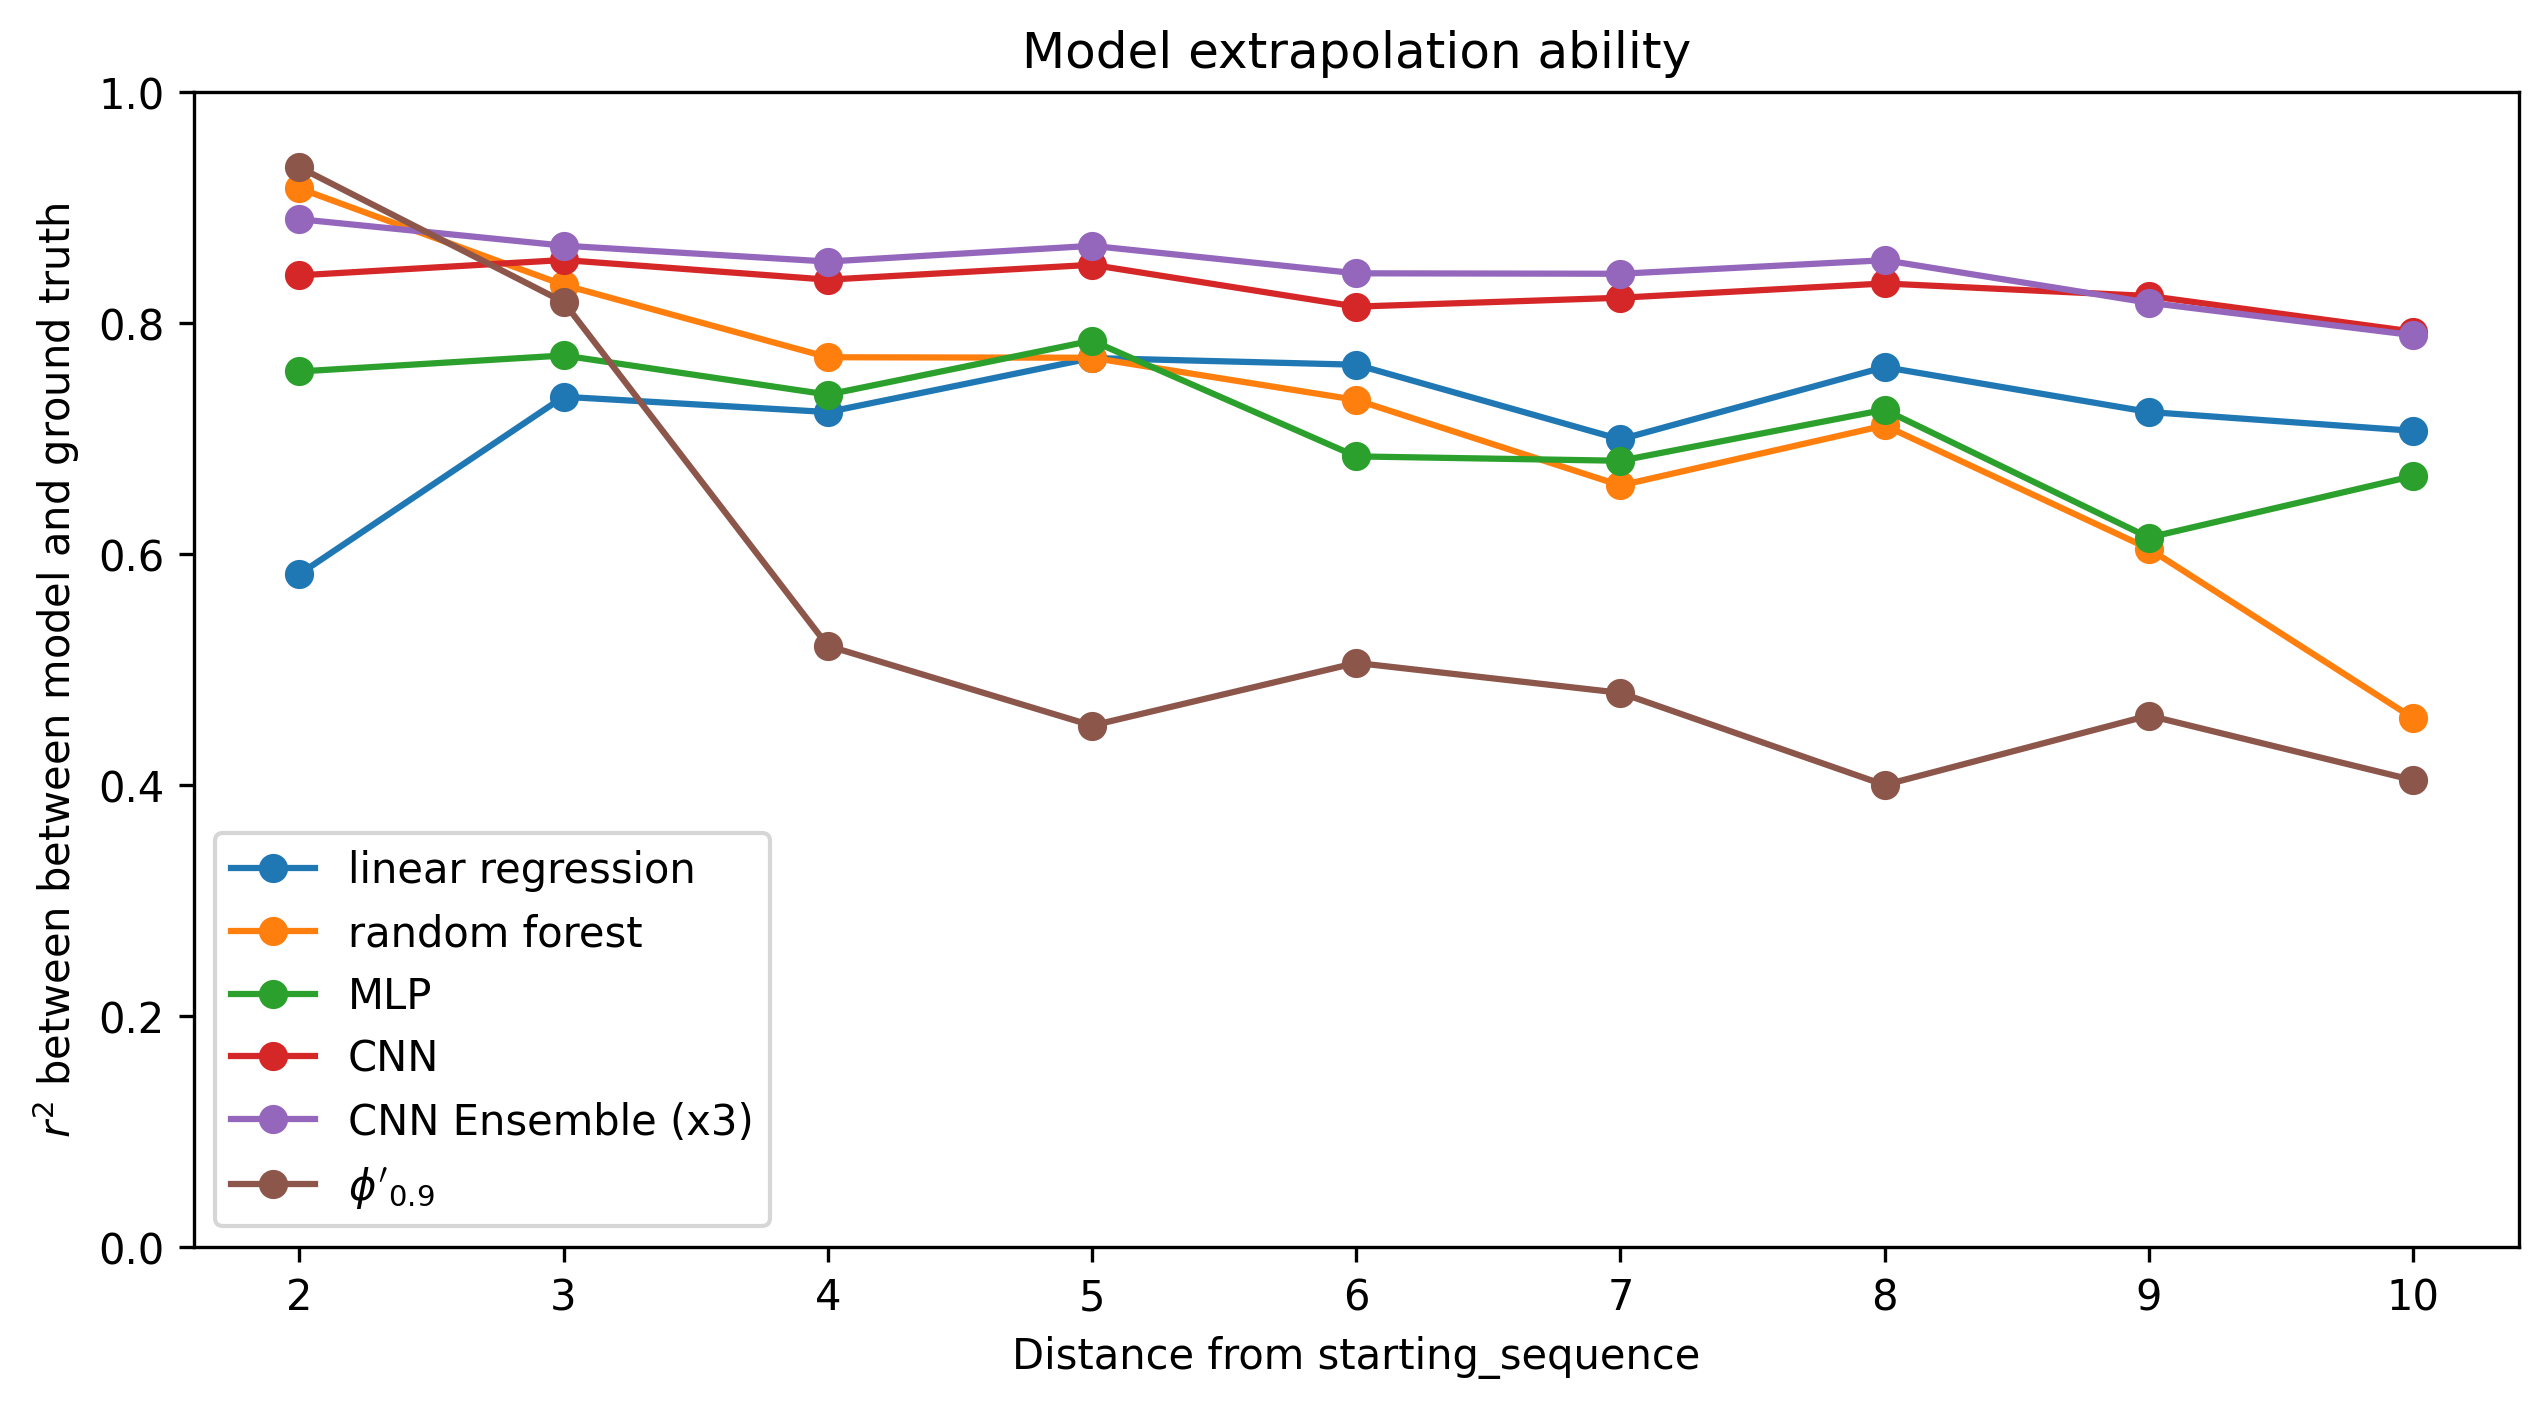

In [27]:
plt.figure(figsize=(10,5), dpi=300)
plt.title('Model extrapolation ability')
plt.plot(range(1,11), corrs_linear, 'o-', label="linear regression")
plt.plot(range(1,11), corrs_rf, 'o-', label="random forest")
plt.plot(range(1,11), corrs_mlp, 'o-', label="MLP")
plt.plot(range(1,11), corrs_cnn, 'o-', label="CNN")
plt.plot(range(1, 11), corrs_cnn_ensemble, 'o-', label="CNN Ensemble (x3)")
plt.plot(range(1,11), corrs_noisy_neighbors[1], 'o-', label="$\phi'_{0.9}$")
plt.ylabel("$r^2$ between between model and ground truth")
plt.xlabel("Distance from starting_sequence")
plt.legend()
plt.ylim(0, 1)
plt.show()

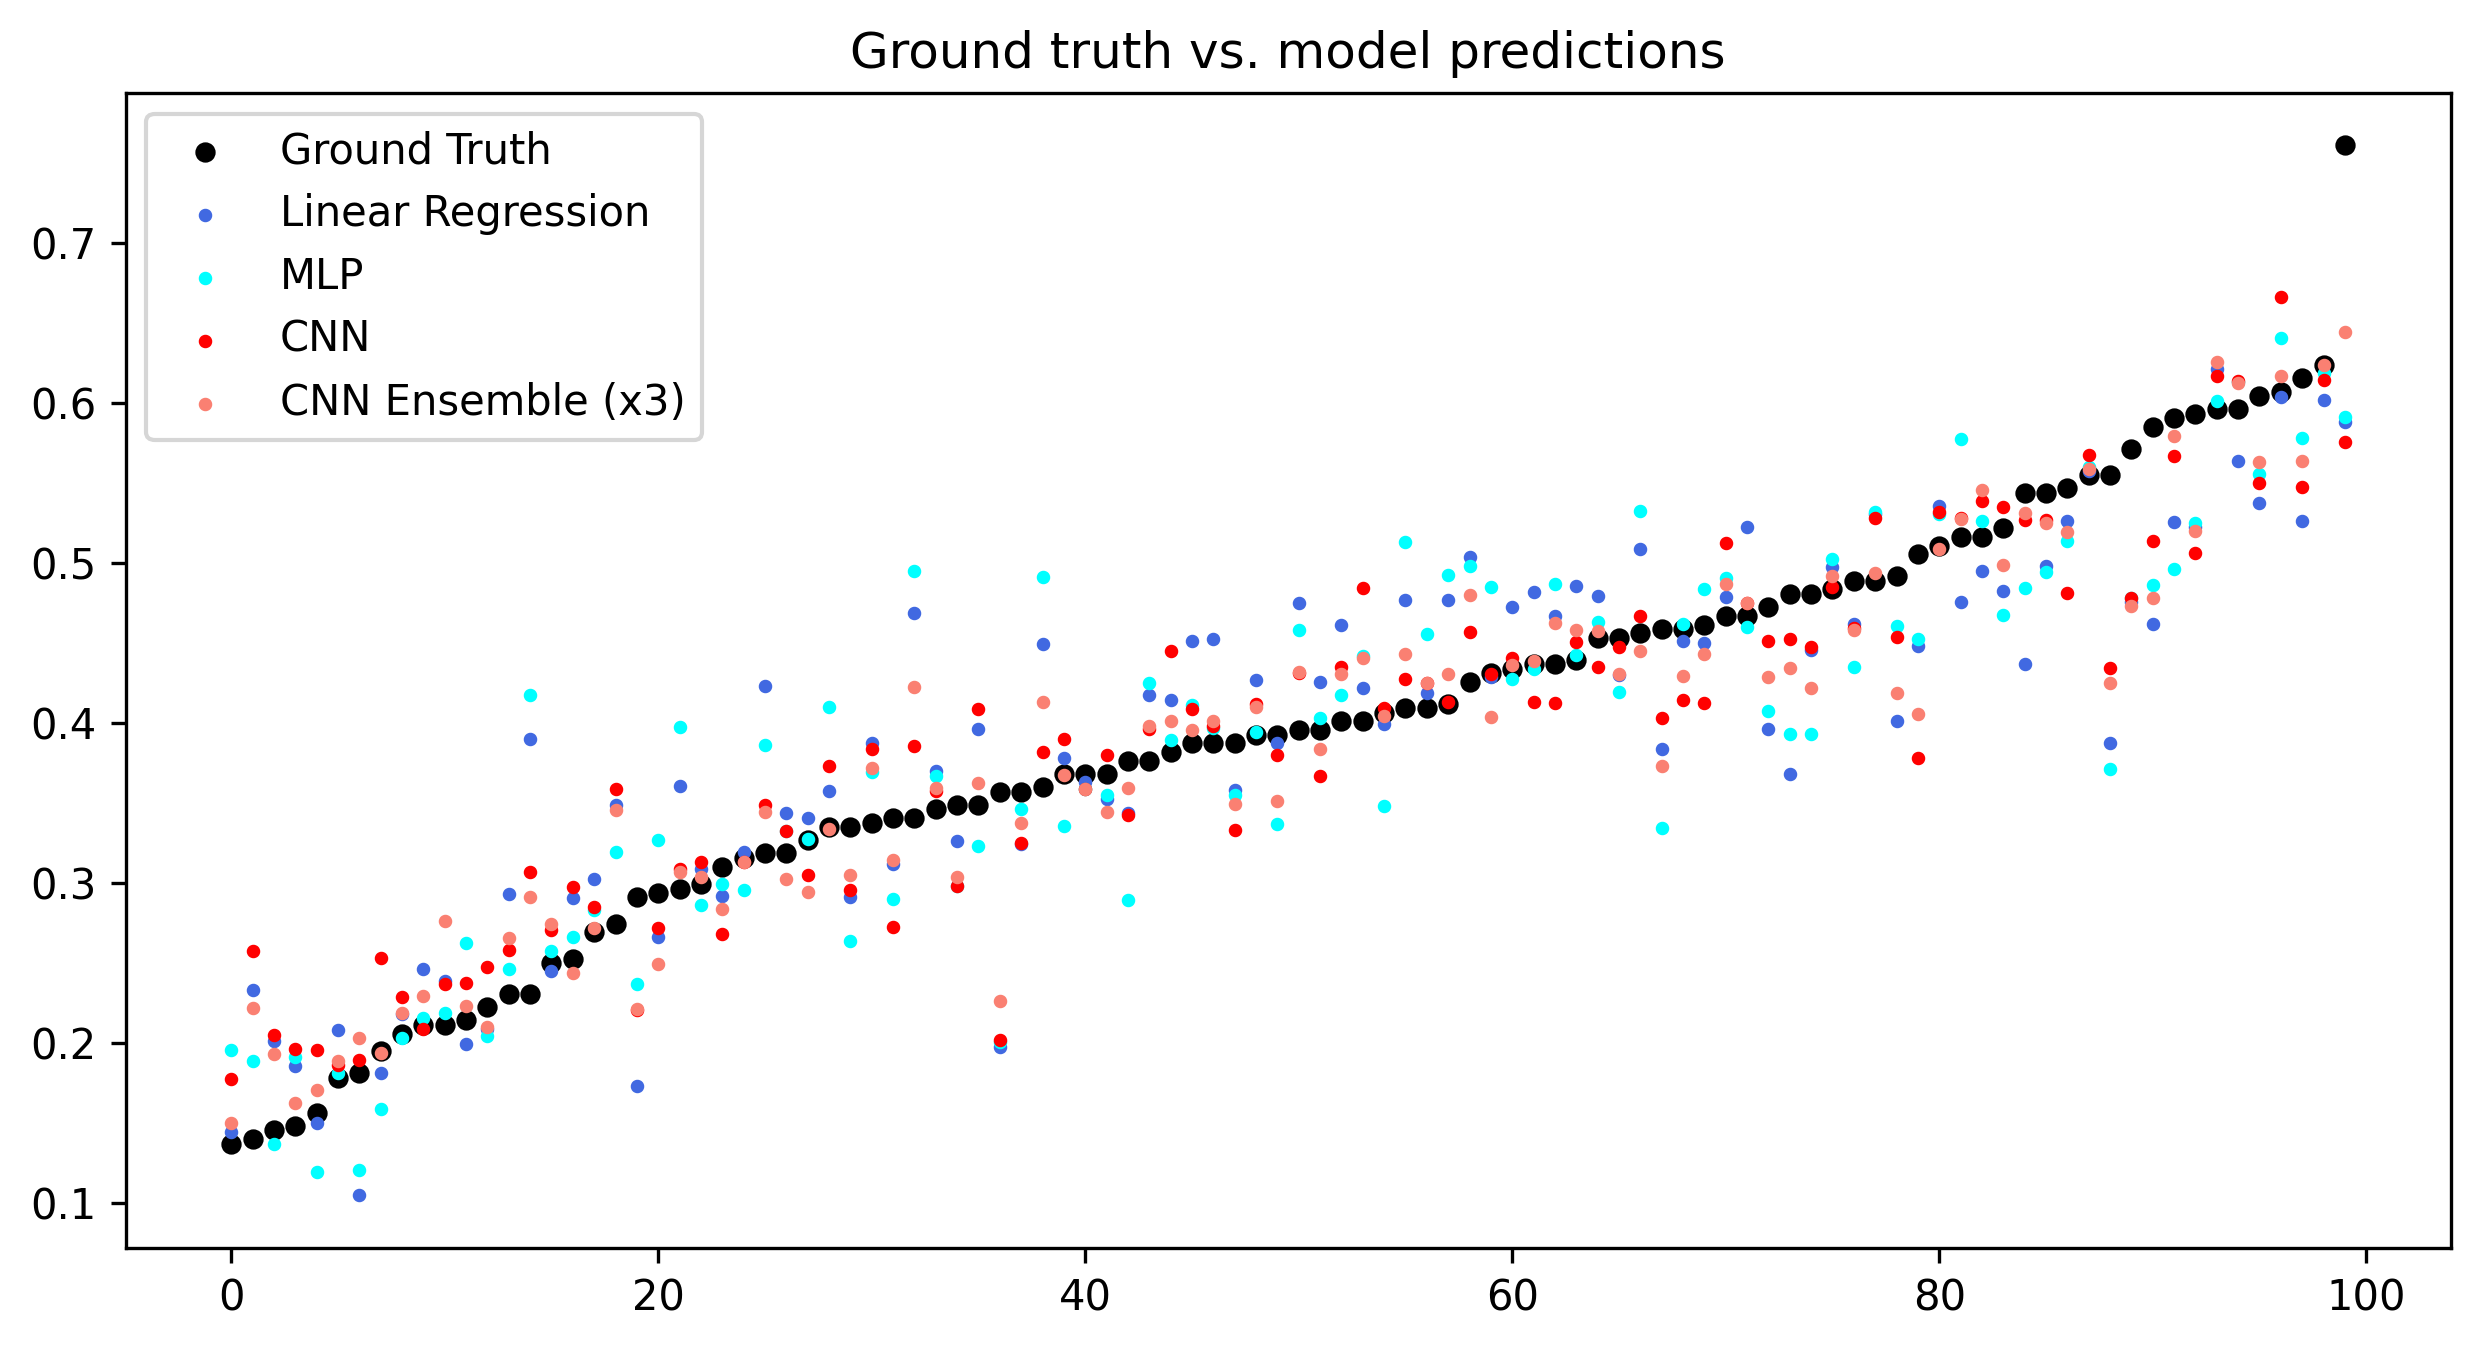

In [28]:
sort_order = np.argsort(test_y[:100])

plt.figure(figsize=(10,5), dpi=300)
plt.title('Ground truth vs. model predictions')
plt.scatter(range(len(sort_order)), test_y[sort_order], c="k", s=15, label="Ground Truth")
plt.scatter(range(len(sort_order)), linear_regression_preds[sort_order], c="royalblue", s=5, label="Linear Regression")
plt.scatter(range(len(sort_order)), mlp_preds[sort_order], c="cyan", s=5, label="MLP")
plt.scatter(range(len(sort_order)), cnn_preds[sort_order], c="red", s=5, label="CNN")
plt.scatter(range(len(sort_order)), cnn_ensemble_preds[sort_order], c="salmon", s=5, label="CNN Ensemble (x3)")

plt.legend()
plt.show()

Now that we have models, we can use them with an exploration algorithm to search the landscape. 

## 3. Exploring the landscape with a model <a class="anchor" id="section-three"></a>

All exploration algorithms in this package inherit from a base `Explorer` which performs some house-keeping tasks. To implement a new explorer, just implement the `propose_sequences` method, which suggest new sequences at each round.

Start with a simple explorer that does random search.

In [29]:
cnn = baselines.models.CNN(len(starting_sequence), alphabet=alphabet,
                         num_filters=32, hidden_size=100, loss='MSE')

random_explorer = baselines.explorers.Random(
    cnn,
    rounds=10,
    mu=1,
    starting_sequence=starting_sequence,
    sequences_batch_size=100,
    model_queries_per_batch=2000,
    alphabet=alphabet
)

- `sequences_batch_size` denotes the experimental batch size per round
- `model_queries_per_batch` is the number of computational queries to the model that is allowed per round. 
- `alphabet` is the alphabet that is permissive on the current landscape.

The `run` method returns a dataframe with the sequences and some other important information.

In [30]:
random_sequences, metadata = random_explorer.run(landscape)
random_sequences

round: 0, top: 0.5437468768175177, time: 0.000325s


round: 1, top: 0.6151479950813181, time: 1.195501s
round: 2, top: 0.6508485804029885, time: 0.347290s
round: 3, top: 0.7634425930879556, time: 0.376798s
round: 4, top: 0.7634425930879556, time: 0.447764s
round: 5, top: 0.7634425930879556, time: 0.458644s
round: 6, top: 0.7634425930879556, time: 0.500393s
round: 7, top: 0.7634425930879556, time: 0.565492s
round: 8, top: 0.7634425930879556, time: 0.579904s
round: 9, top: 0.8101279537472399, time: 0.643980s
round: 10, top: 0.8101279537472399, time: 0.657886s


,sequence,model_score,true_score,round,model_cost,measurement_cost
0,AUGGGCCGGACCCC,NaN,0.543747,0,0,1
0,AUGGCACGGACCCG,0.432926,0.439391,1,2001,101
1,AUGGACCUGACUCC,0.482026,0.241665,1,2001,101
2,AAGGGGUGGACCCC,0.375842,0.458615,1,2001,101
3,CUGGGCCGGACUCC,0.486699,0.516285,1,2001,101
...,...,...,...,...,...,...
95,AUGGCCUGUAUCGG,0.369554,0.346021,10,20010,1001
96,AUUUGCUGCUCCCC,0.444065,0.417422,10,20010,1001
97,AGUUGCUGGUACCC,0.386823,0.324051,10,20010,1001
98,AGGACUCUAACUAC,0.207563,0.183995,10,20010,1001


We will compare performance among several explorers over 10 rounds with a sequences_batch_size of 100 and model_queries_per_batch size of 1000.

In [31]:
cnn = baselines.models.CNN(len(starting_sequence), alphabet=alphabet,
                         num_filters=32, hidden_size=100, loss='MSE')

adalead_explorer = baselines.explorers.Adalead(
    cnn,
    rounds=10,
    starting_sequence=starting_sequence,
    sequences_batch_size=100,
    model_queries_per_batch=2000,
    alphabet=alphabet
)

In [32]:
adalead_sequences, metadata = adalead_explorer.run(landscape)

round: 0, top: 0.5437468768175177, time: 0.000298s


round: 1, top: 0.6563409418820252, time: 3.444078s
round: 2, top: 0.7359806285541509, time: 2.919722s
round: 3, top: 0.7936507645510489, time: 2.924034s
round: 4, top: 0.8952600018984022, time: 2.998625s
round: 5, top: 0.9831383093583935, time: 3.105957s
round: 6, top: 0.9831383093583935, time: 2.871208s
round: 7, top: 0.9831383093583935, time: 2.887202s
round: 8, top: 0.9831383093583935, time: 2.991915s
round: 9, top: 0.9831383093583935, time: 2.978744s
round: 10, top: 0.9831383093583935, time: 3.474497s


In [33]:
cnn = baselines.models.CNN(len(starting_sequence), alphabet=alphabet,
                         num_filters=32, hidden_size=100, loss='MSE')

genetic_explorer = baselines.explorers.GeneticAlgorithm(
    cnn,
    
    population_size=20,
    parent_selection_strategy='wright-fisher', # wright-fisher model decides who gets to 'mate'
    beta=0.01,
    children_proportion=0.2,

    rounds=10,
    starting_sequence=starting_sequence,
    sequences_batch_size=100,
    model_queries_per_batch=1000,
    alphabet=alphabet
)

In [34]:
genetic_algo_sequences, metadata = genetic_explorer.run(landscape)

round: 0, top: 0.5437468768175177, time: 0.000307s


round: 1, top: 0.6453561665444114, time: 15.140036s
round: 2, top: 0.7085186640203461, time: 17.929057s
round: 3, top: 0.7881584030720123, time: 19.218744s
round: 4, top: 0.8623056758855608, time: 19.410753s
round: 5, top: 0.9556763448245889, time: 19.922409s
round: 6, top: 0.9556763448245889, time: 18.812026s
round: 7, top: 0.9556763448245889, time: 19.841472s
round: 8, top: 0.9556763448245889, time: 19.591023s
round: 9, top: 0.9556763448245889, time: 20.844541s
round: 10, top: 0.9556763448245889, time: 20.640786s


In [35]:
cnn = baselines.models.CNN(len(starting_sequence), alphabet=alphabet,
                         num_filters=32, hidden_size=100, loss='MSE')

cmaes_explorer = baselines.explorers.CMAES(
    flexs.LandscapeAsModel(landscape),
    
    population_size=10,
    max_iter=200,
    
    rounds=10,
    starting_sequence=starting_sequence,
    sequences_batch_size=100,
    model_queries_per_batch=1000,
    alphabet=alphabet
)

In [36]:
cmaes_sequences, metadata = cmaes_explorer.run(landscape)

round: 0, top: 0.5437468768175177, time: 0.000341s


round: 1, top: 0.5492392906760948, time: 0.596336s
round: 2, top: 0.6261327704189319, time: 0.532873s
round: 3, top: 0.6700719241489276, time: 0.655862s
round: 4, top: 0.6892953202744071, time: 0.651521s
round: 5, top: 0.6892953202744071, time: 0.810897s
round: 6, top: 0.7387268354834394, time: 0.625638s
round: 7, top: 0.7387268354834394, time: 0.642060s
round: 8, top: 0.867798089744138, time: 0.651786s
round: 9, top: 0.889767692798906, time: 0.643483s
round: 10, top: 0.889767692798906, time: 0.677559s


In [37]:
dynappo_explorer = baselines.explorers.DynaPPO(  # DynaPPO has its own default ensemble model, so don't use CNN
    landscape=landscape,
    env_batch_size=10,
    num_model_rounds=10,
    rounds=10,
    starting_sequence=starting_sequence,
    sequences_batch_size=100,
    model_queries_per_batch=1000,
    alphabet=alphabet,
)

/home/v-zhaozhiyu/miniconda3/envs/FLEXS/lib/python3.7/site-packages/sklearn/linear_model/_coordinate_descent.py:531: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 0.0, tolerance: 0.0
  positive)


In [38]:
dynappo_sequences, metadata = dynappo_explorer.run(landscape)

round: 0, top: 0.5437468768175177, time: 0.000399s
Instructions for updating:
Use `as_dataset(..., single_deterministic_pass=True)` instead.
round: 1, top: 0.6755643380075047, time: 9.215455s
round: 2, top: 0.7085186640203461, time: 11.464586s
round: 3, top: 0.7497116108210532, time: 14.321028s
round: 4, top: 0.7524578177503418, time: 14.768383s
round: 5, top: 0.7524578177503418, time: 15.874852s
round: 6, top: 0.7524578177503418, time: 17.306957s
round: 7, top: 0.815620367605817, time: 17.425879s
round: 8, top: 0.815620367605817, time: 18.546002s
round: 9, top: 0.815620367605817, time: 19.192130s
round: 10, top: 0.815620367605817, time: 20.145293s


In [39]:
cnn = baselines.models.CNN(len(starting_sequence), alphabet=alphabet,
                         num_filters=32, hidden_size=100, loss='MSE')

vae = baselines.explorers.VAE(len(starting_sequence), alphabet=alphabet, epochs=10, verbose=False)

cbas_explorer = baselines.explorers.CbAS(
    model=cnn,
    generator=vae,
    cycle_batch_size=100,
    rounds=10,
    starting_sequence=starting_sequence,
    sequences_batch_size=100,
    model_queries_per_batch=2000,
    alphabet=alphabet,
)

In [40]:
cbas_sequences, metadata = cbas_explorer.run(landscape)

round: 0, top: 0.5437468768175177, time: 0.000351s


/home/v-zhaozhiyu/miniconda3/envs/FLEXS/lib/python3.7/site-packages/tensorflow/python/data/ops/dataset_ops.py:3350: UserWarning: Even though the tf.config.experimental_run_functions_eagerly option is set, this option does not apply to tf.data functions. tf.data functions are still traced and executed as graphs.
  "Even though the tf.config.experimental_run_functions_eagerly "


round: 1, top: 0.7222496462872485, time: 0.410732s


/home/v-zhaozhiyu/miniconda3/envs/FLEXS/lib/python3.7/site-packages/tensorflow/python/data/ops/dataset_ops.py:3350: UserWarning: Even though the tf.config.experimental_run_functions_eagerly option is set, this option does not apply to tf.data functions. tf.data functions are still traced and executed as graphs.
  "Even though the tf.config.experimental_run_functions_eagerly "


round: 2, top: 0.7222496462872485, time: 230.919735s


...

round: 8, top: 0.7222496462872485, time: 192.487268s


/home/v-zhaozhiyu/miniconda3/envs/FLEXS/lib/python3.7/site-packages/tensorflow/python/data/ops/dataset_ops.py:3350: UserWarning: Even though the tf.config.experimental_run_functions_eagerly option is set, this option does not apply to tf.data functions. tf.data functions are still traced and executed as graphs.
  "Even though the tf.config.experimental_run_functions_eagerly "


round: 9, top: 0.7222496462872485, time: 226.735749s


/home/v-zhaozhiyu/miniconda3/envs/FLEXS/lib/python3.7/site-packages/tensorflow/python/data/ops/dataset_ops.py:3350: UserWarning: Even though the tf.config.experimental_run_functions_eagerly option is set, this option does not apply to tf.data functions. tf.data functions are still traced and executed as graphs.
  "Even though the tf.config.experimental_run_functions_eagerly "


round: 10, top: 0.7222496462872485, time: 217.628683s


In [41]:
cnn = baselines.models.CNN(len(starting_sequence), alphabet=alphabet,
                         num_filters=32, hidden_size=100, loss='MSE')

# This is `EVO_BO` in the paper, an evolutionary algorithm using
# ensembled models (when provided) to estimate uncertainty
bo_explorer = baselines.explorers.BO(
    model=cnn,
    rounds=10,
    starting_sequence=starting_sequence,
    sequences_batch_size=100,
    model_queries_per_batch=1000,
    alphabet=alphabet,
)

In [42]:
bo_sequences, metadata = bo_explorer.run(landscape)

round: 0, top: 0.5437468768175177, time: 0.000404s


round: 1, top: 0.6343713912067976, time: 3.638608s


/home/v-zhaozhiyu/miniconda3/envs/FLEXS/lib/python3.7/site-packages/tensorflow/python/data/ops/dataset_ops.py:3350: UserWarning: Even though the tf.config.experimental_run_functions_eagerly option is set, this option does not apply to tf.data functions. tf.data functions are still traced and executed as graphs.
  "Even though the tf.config.experimental_run_functions_eagerly "


round: 2, top: 0.6673257172196391, time: 3.566197s


/home/v-zhaozhiyu/miniconda3/envs/FLEXS/lib/python3.7/site-packages/tensorflow/python/data/ops/dataset_ops.py:3350: UserWarning: Even though the tf.config.experimental_run_functions_eagerly option is set, this option does not apply to tf.data functions. tf.data functions are still traced and executed as graphs.
  "Even though the tf.config.experimental_run_functions_eagerly "


...

round: 8, top: 0.7332344740044028, time: 4.414172s


/home/v-zhaozhiyu/miniconda3/envs/FLEXS/lib/python3.7/site-packages/tensorflow/python/data/ops/dataset_ops.py:3350: UserWarning: Even though the tf.config.experimental_run_functions_eagerly option is set, this option does not apply to tf.data functions. tf.data functions are still traced and executed as graphs.
  "Even though the tf.config.experimental_run_functions_eagerly "


round: 9, top: 0.8375899182810447, time: 4.704300s


/home/v-zhaozhiyu/miniconda3/envs/FLEXS/lib/python3.7/site-packages/tensorflow/python/data/ops/dataset_ops.py:3350: UserWarning: Even though the tf.config.experimental_run_functions_eagerly option is set, this option does not apply to tf.data functions. tf.data functions are still traced and executed as graphs.
  "Even though the tf.config.experimental_run_functions_eagerly "


round: 10, top: 0.8375899182810447, time: 4.634628s


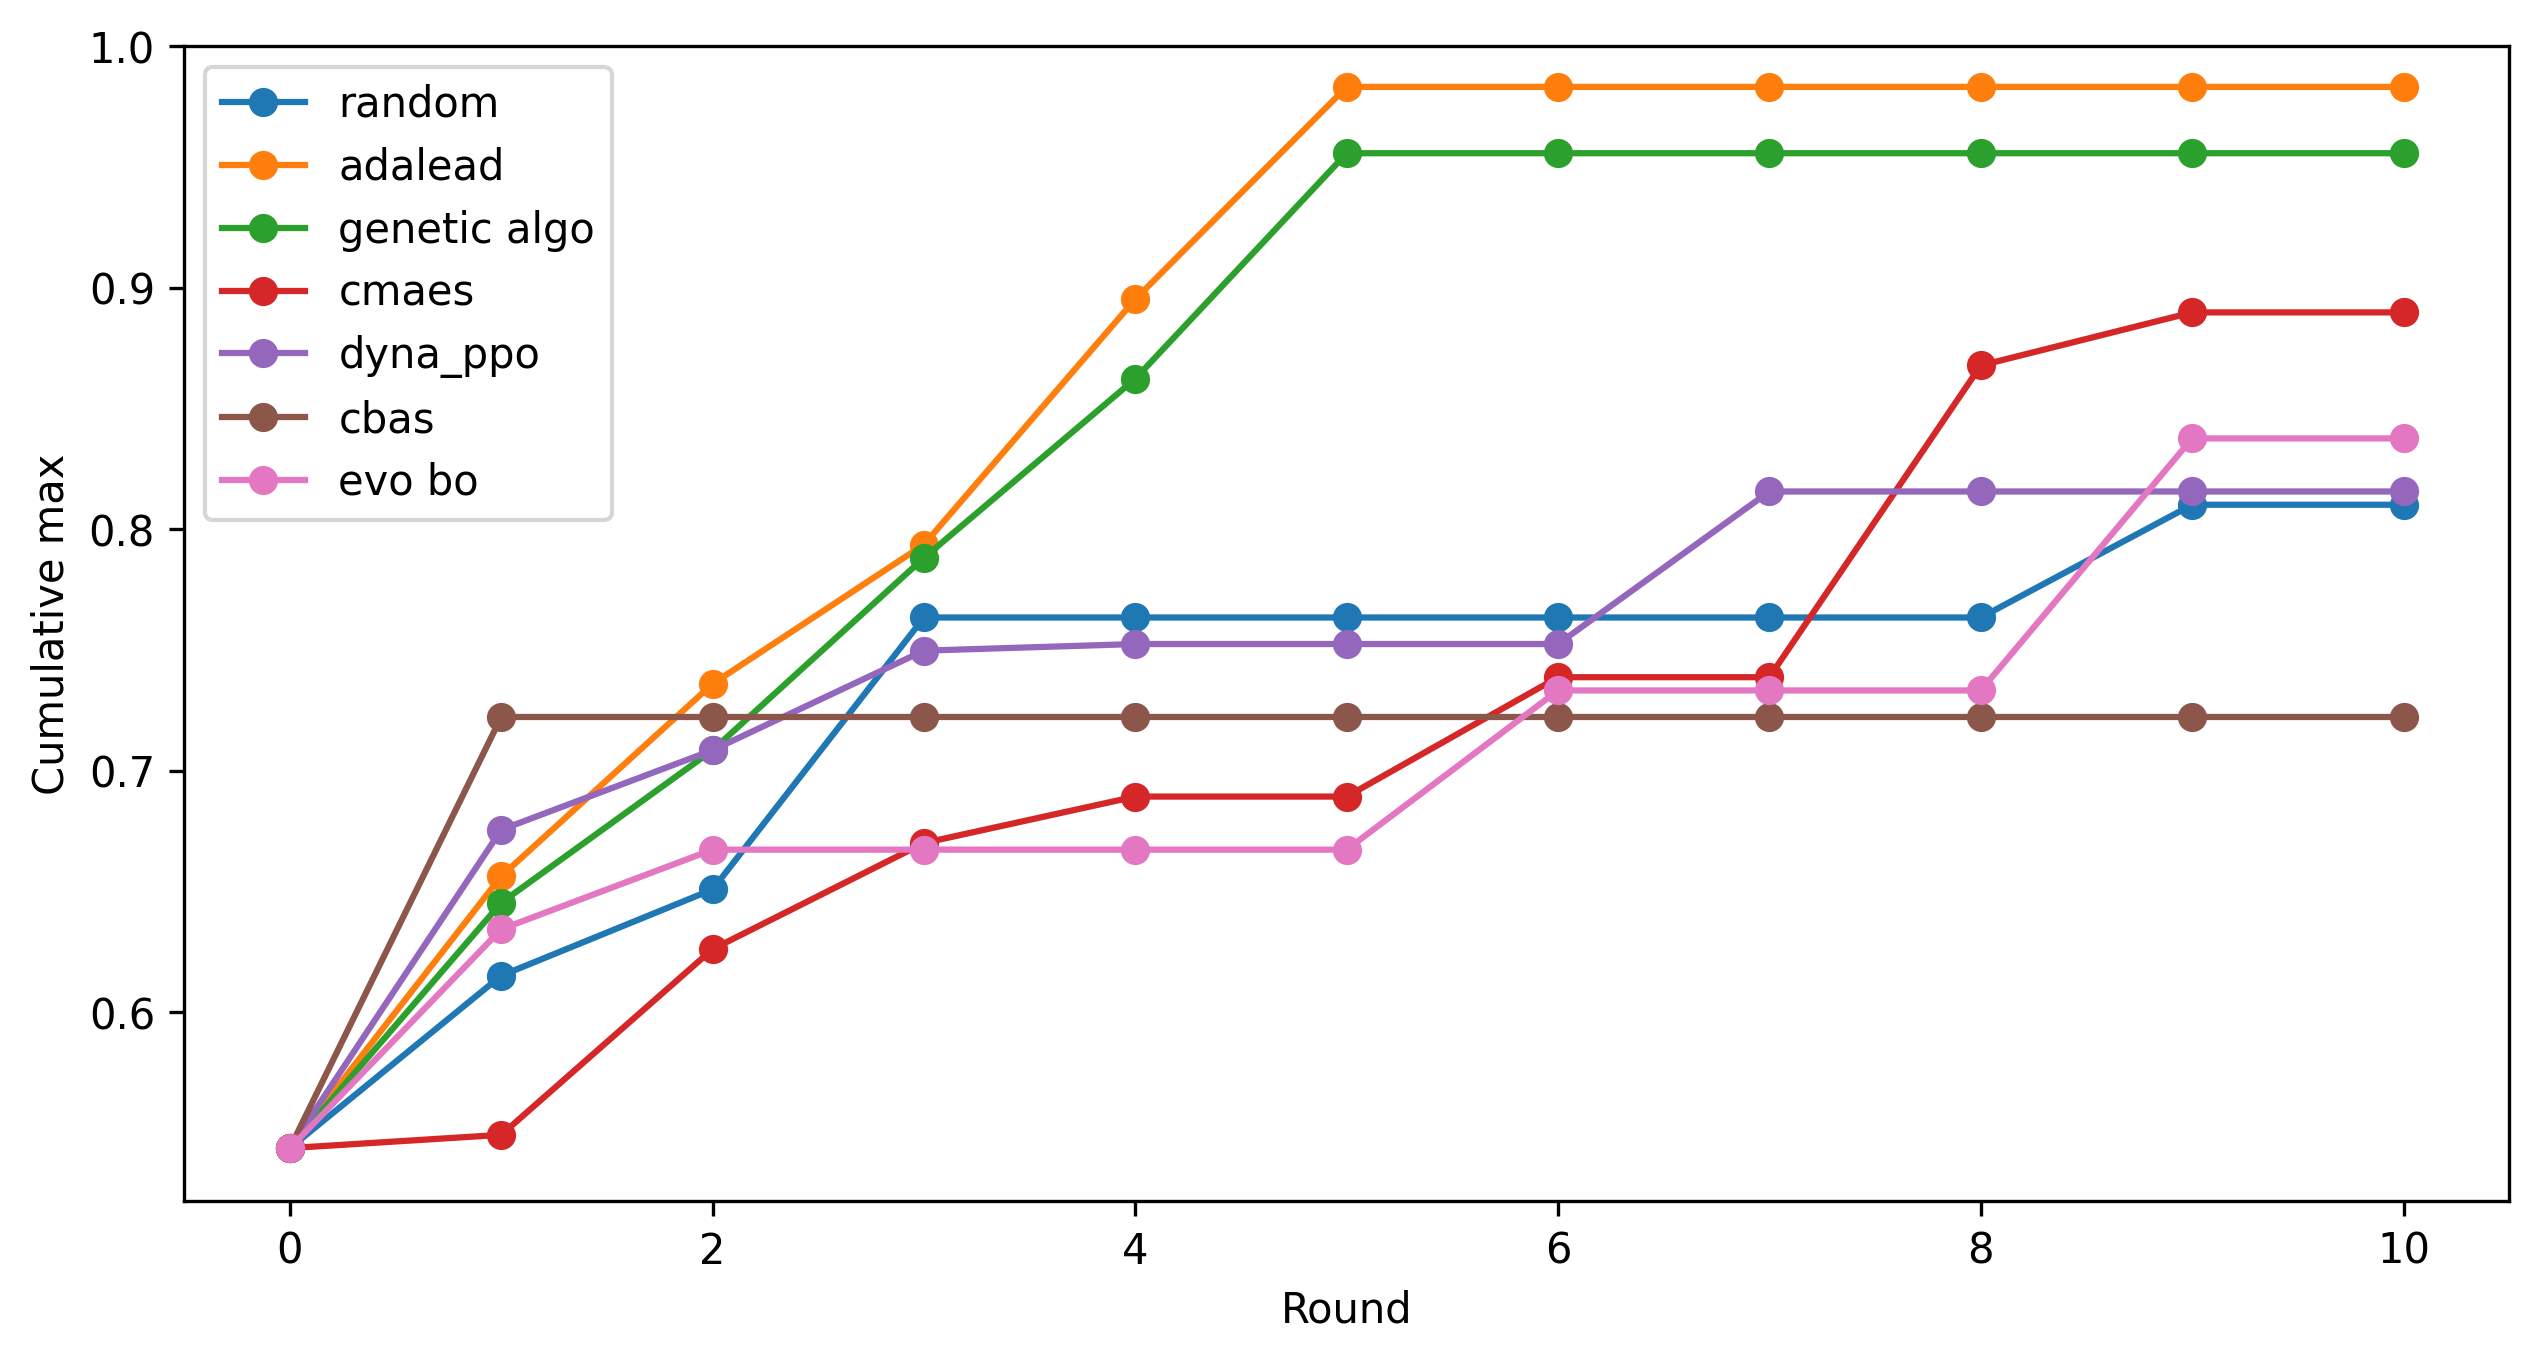

In [43]:
def cumulative_max_per_round(sequences):
    num_rounds = sequences['round'].max() + 1
    max_per_round = [sequences['true_score'][sequences['round'] == r].max()
                     for r in range(num_rounds)]

    return np.maximum.accumulate(max_per_round)

plt.figure(figsize=(10,5), dpi=300)
plt.plot(range(11), cumulative_max_per_round(random_sequences), 'o-', label="random")
plt.plot(range(11), cumulative_max_per_round(adalead_sequences), 'o-', label="adalead")
plt.plot(range(11), cumulative_max_per_round(genetic_algo_sequences), 'o-', label="genetic algo")
plt.plot(range(11), cumulative_max_per_round(cmaes_sequences), 'o-', label="cmaes")
plt.plot(range(11), cumulative_max_per_round(dynappo_sequences), 'o-', label="dyna_ppo")
plt.plot(range(11), cumulative_max_per_round(cbas_sequences), 'o-', label="cbas")
plt.plot(range(11), cumulative_max_per_round(bo_sequences), 'o-', label="evo bo")
plt.ylabel("Cumulative max")
plt.xlabel("Round")
plt.legend()
plt.ylim(None, 1)
plt.show()

## 4. Evaluating an exploration algorithm <a class="anchor" id="section-four"></a>


The `flexs.evaluate` module can be used run tests aimed at different properties of the explorer. 

Tests include:
- `robustness`: shows how explorer performance changes with model quality (noisy abstract models at different signal strengths).
- `efficiency`: shows how explorer performance changes when more computational evals are allowed
- `adaptivity`: shows how the explorer is sensitive to the number of batches it is allowed to sample

In most cases, you want to set the `log_dir` argument on the explorer to write output to a .csv file to analyze later.

Here we will test out Adalead's robustness to varying model quality.

In [44]:
def make_explorer(model, signal_strength):
    return baselines.explorers.Adalead(
            model,
            rounds=5,
            mu=1,
            starting_sequence=starting_sequence,
            sequences_batch_size=100,
            model_queries_per_batch=1000,
            alphabet=alphabet,
            log_file=f'robustness/adalead/{signal_strength}.csv'
        )

results = flexs.evaluate.robustness(landscape, make_explorer, signal_strengths=[0, 0.5, 0.75, 0.9, 1])

Evaluating for robustness with model accuracy; signal_strength: 0
round: 0, top: 0.5437468768175177, time: 0.002137s


round: 1, top: 0.6892953202744071, time: 1.364401s
round: 2, top: 0.815620367605817, time: 1.666660s
round: 3, top: 0.9337067941493612, time: 1.882280s
round: 4, top: 0.9419453625576865, time: 1.944841s
round: 5, top: 0.9419453625576865, time: 1.814438s
Evaluating for robustness with model accuracy; signal_strength: 0.5
round: 0, top: 0.5437468768175177, time: 0.000814s
round: 1, top: 0.7222496462872485, time: 1.387515s
round: 2, top: 0.7826659892134351, time: 1.487364s
round: 3, top: 0.889767692798906, time: 1.778497s
round: 4, top: 0.889767692798906, time: 2.628289s
round: 5, top: 0.889767692798906, time: 1.541506s
Evaluating for robustness with model accuracy; signal_strength: 0.75
round: 0, top: 0.5437468768175177, time: 0.000772s
round: 1, top: 0.7634425930879556, time: 1.434463s
round: 2, top: 0.8430823321396218, time: 1.500300s
round: 3, top: 0.8430823321396218, time: 1.700247s
round: 4, top: 0.8650518828148493, time: 1.551615s
round: 5, top: 0.889767692798906, time: 1.620358s
E

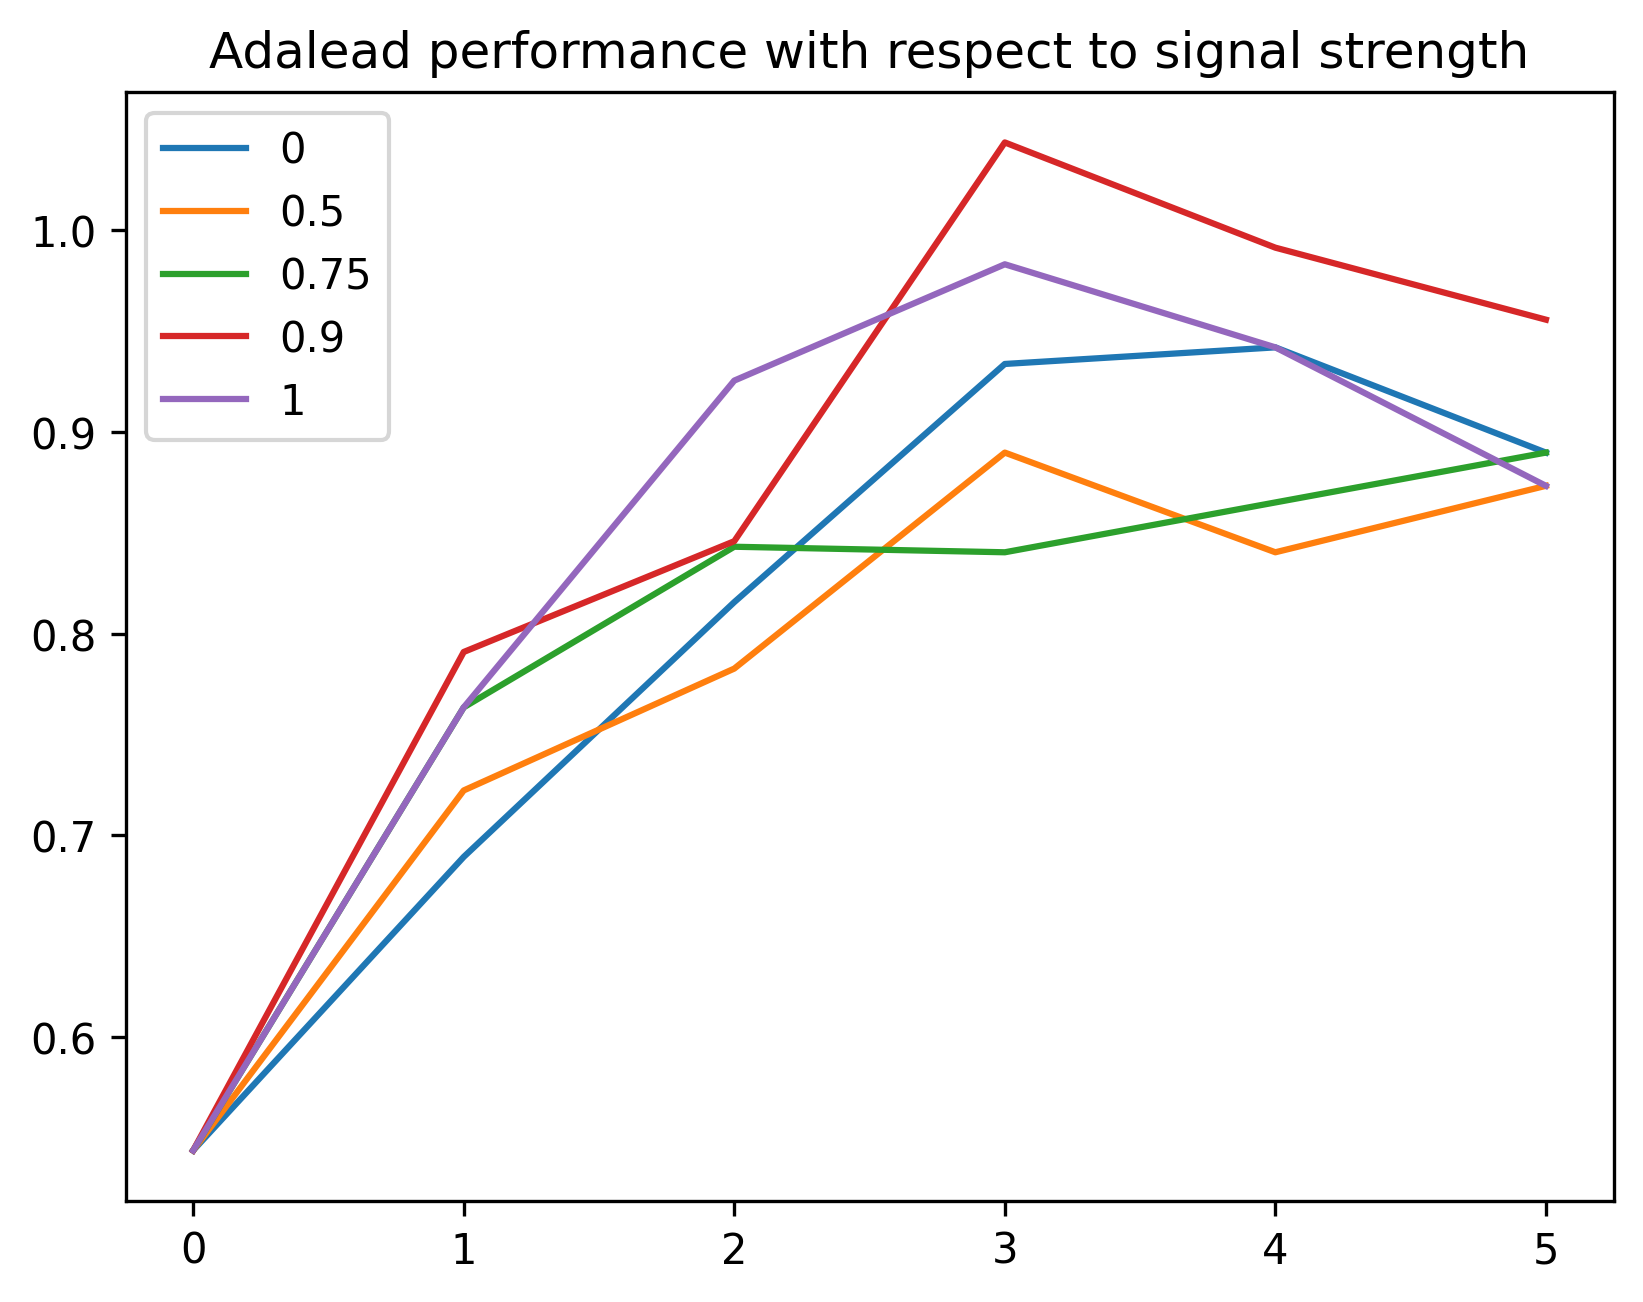

In [46]:
plt.figure(dpi=300)
plt.title('Adalead performance with respect to signal strength')

# The output file contains metadata on the first line
for signal_strength in [0, 0.5, 0.75, 0.9, 1]:
    with open(f'robustness/adalead/{signal_strength}.csv') as f:
        metadata = json.loads(next(f))
        data = pd.read_csv(f)
    
    rounds = data['round'].unique()
    
    plt.plot(rounds, [data[data['round'] == r]['true_score'].max() for r in rounds], label=signal_strength)

plt.legend()

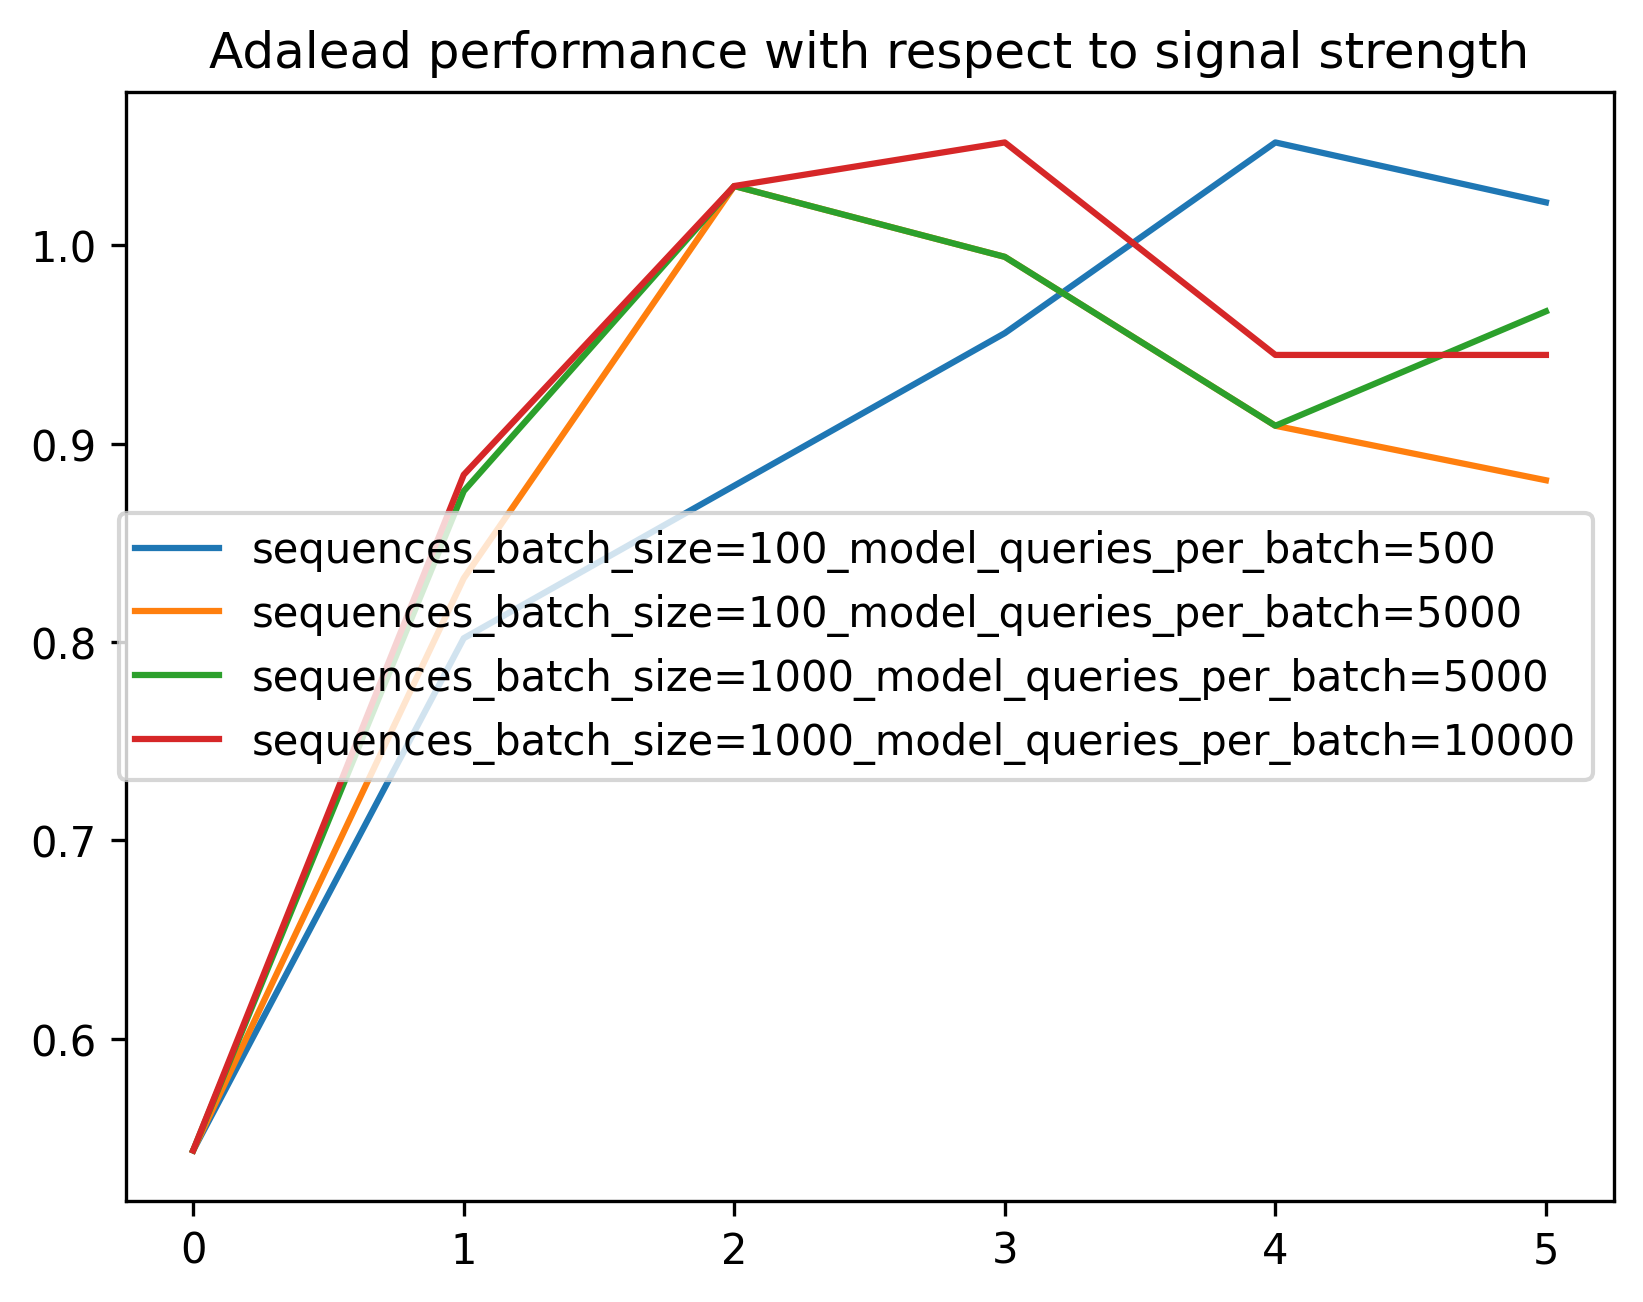

In [18]:
import matplotlib.pyplot as plt
plt.figure(dpi=300)
plt.title('Adalead performance with respect to signal strength')


for sequences_batch_size, model_queries_per_batch in [(100, 500), (100, 5000),(1000, 5000),(1000, 10000)]:
    with open(f'/home/v-zhaozhiyu/code/FLEXS/efficiency/adalead/{sequences_batch_size}_{model_queries_per_batch}.csv') as f:
        metadata = json.loads(next(f))
        data = pd.read_csv(f)

    rounds = data['round'].unique()

    plt.plot(rounds, [data[data['round'] == r]['true_score'].max() for r in rounds], label=f'sequences_batch_size={sequences_batch_size}_model_queries_per_batch={model_queries_per_batch}')

plt.legend()